<a href="https://colab.research.google.com/github/young-suh/ESAA_2026/blob/main/week3_note_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **\# 목표**
사용자의 다음 주문에 어떤 상품이 포함될지 예측

### **\# 데이터셋**

- 20만 명 이상의 Instacart 사용자로부터 수집된 300만 건 이상의 식료품 주문 데이터를 포함

- 각 사용자에 대해 4~100개의 주문 정보(상품 목록, 순서) 제공



In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()

%matplotlib inline

pd.options.mode.chained_assignment = None  # default='warn'


In [2]:
order_products_train_df = pd.read_csv("/content/drive/MyDrive/ESAA_data/3주차 캐글 과제/order_products__train.csv")
order_products_prior_df = pd.read_csv("/content/drive/MyDrive/ESAA_data/3주차 캐글 과제/order_products__prior.csv")
orders_df = pd.read_csv("/content/drive/MyDrive/ESAA_data/3주차 캐글 과제/orders.csv")
products_df = pd.read_csv("/content/drive/MyDrive/ESAA_data/3주차 캐글 과제/products.csv")
aisles_df = pd.read_csv("/content/drive/MyDrive/ESAA_data/3주차 캐글 과제/aisles.csv")
departments_df = pd.read_csv("/content/drive/MyDrive/ESAA_data/3주차 캐글 과제/departments.csv")

### **\# 데이터 살펴보기**

In [25]:
orders_df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [26]:
order_products_train_df.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


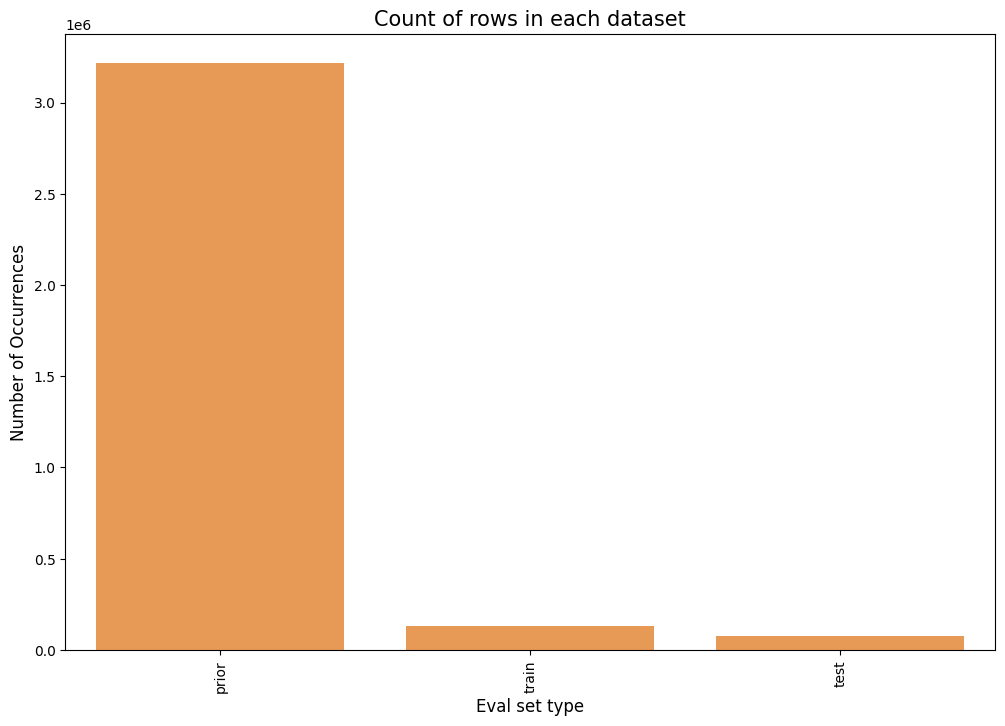

In [27]:
cnt_srs = orders_df.eval_set.value_counts()

plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha=0.8, color=color[1])
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Eval set type', fontsize=12)
plt.title('Count of rows in each dataset', fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

In [28]:
def get_unique_count(x):
  return len(np.unique(x))

cnt_srs = orders_df.groupby("eval_set")["user_id"].aggregate(get_unique_count)
cnt_srs

,user_id
eval_set,
prior,206209
test,75000
train,131209


/tmp/ipykernel_1039/558827441.py:1: FutureWarning: The provided callable <function max at 0x7fd200f23560> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  cnt_srs = orders_df.groupby("user_id")["order_number"].aggregate(np.max).reset_index()


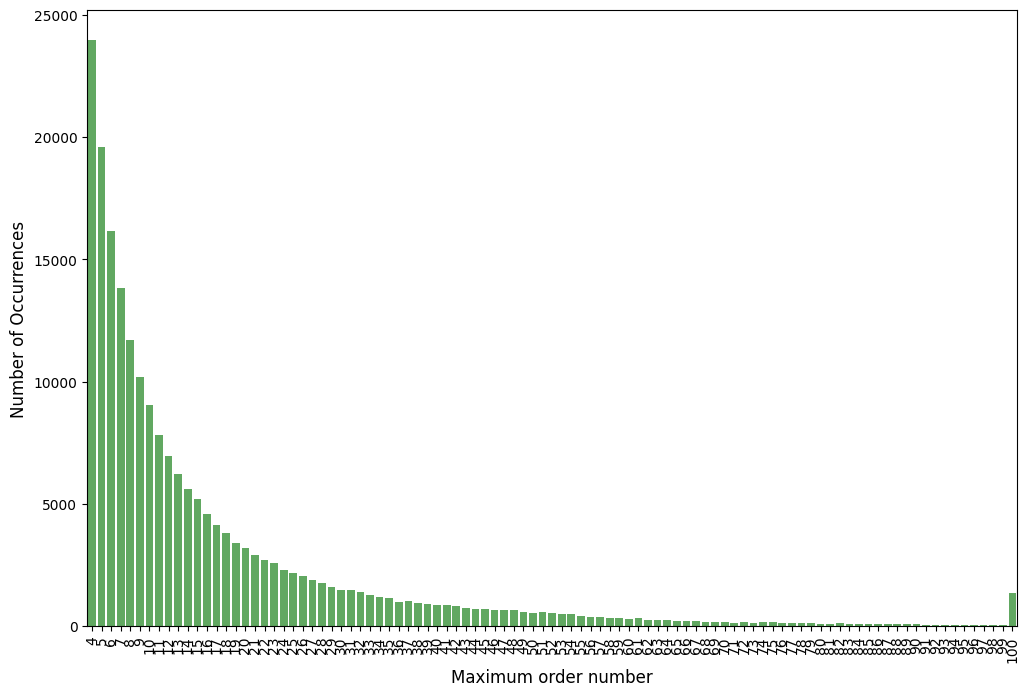

In [29]:
cnt_srs = orders_df.groupby("user_id")["order_number"].aggregate(np.max).reset_index()
cnt_srs = cnt_srs.order_number.value_counts()

plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha=0.8, color=color[2])
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Maximum order number', fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

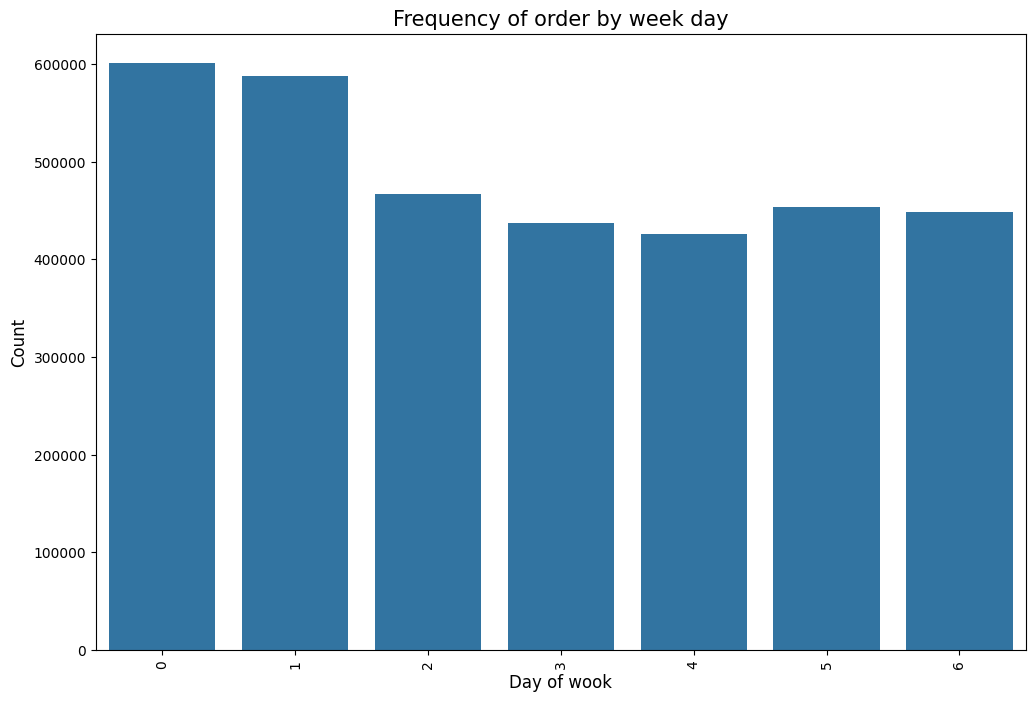

In [30]:
plt.figure(figsize=(12,8))
sns.countplot(x="order_dow", data=orders_df,color=color[0])
plt.ylabel('Count', fontsize=12)
plt.xlabel('Day of wook', fontsize=12)
plt.xticks(rotation='vertical')
plt.title("Frequency of order by week day", fontsize=15)
plt.show()

-> 주말에 주문량이 상대적으로 높고 수요일에 낮은 경향이 나타남.

<function matplotlib.pyplot.show(close=None, block=None)>

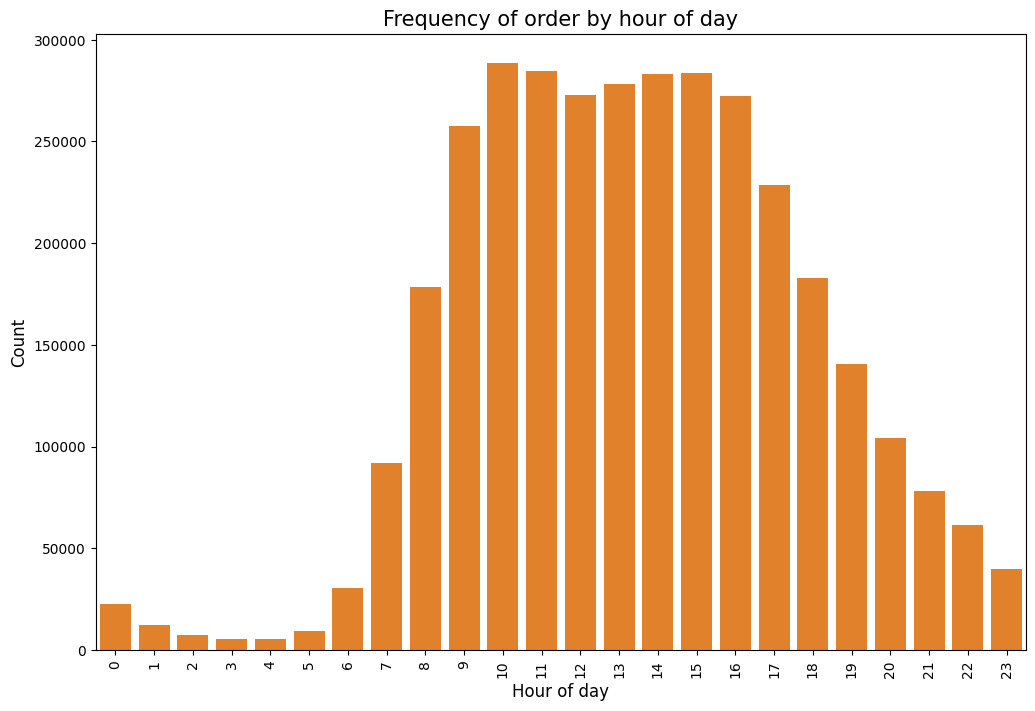

In [31]:
plt.figure(figsize=(12,8))
sns.countplot(x='order_hour_of_day', data=orders_df,color=color[1])
plt.ylabel('Count', fontsize=12)
plt.xlabel('Hour of day', fontsize=12)
plt.xticks(rotation='vertical')
plt.title("Frequency of order by hour of day", fontsize=15)
plt.show

-> 대부분의 주문은 낮 시간에 이루어짐.

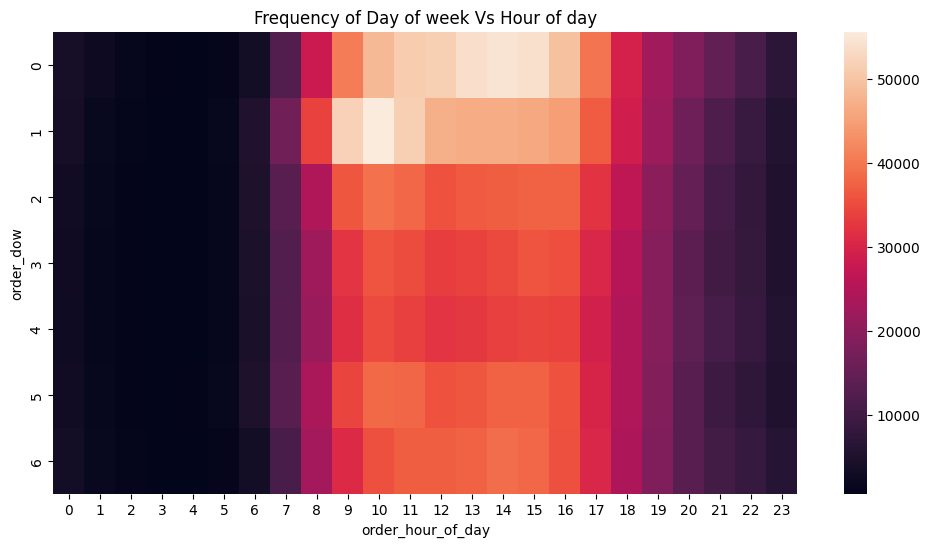

In [32]:
grouped_df = orders_df.groupby(["order_dow", "order_hour_of_day"])["order_number"].aggregate("count").reset_index()
grouped_df = grouped_df.pivot(index='order_dow',columns='order_hour_of_day',values='order_number')

plt.figure(figsize=(12,6))
sns.heatmap(grouped_df)
plt.title("Frequency of Day of week Vs Hour of day")
plt.show()

-> 토요일 저녁과 일요일 아침이 주문이 가장 많은 시간대임.

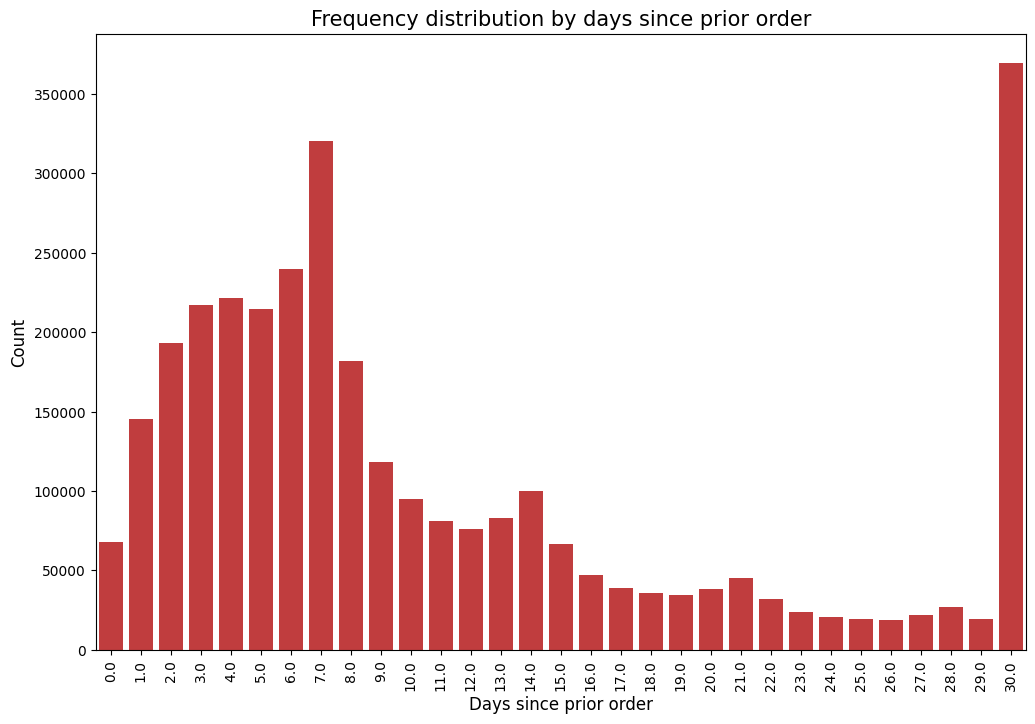

In [33]:
plt.figure(figsize=(12,8))
sns.countplot(x="days_since_prior_order", data=orders_df,color=color[3])
plt.ylabel('Count',fontsize=12)
plt.xlabel('Days since prior order', fontsize=12)
plt.xticks(rotation='vertical')
plt.title("Frequency distribution by days since prior order", fontsize=15)
plt.show()

-> 14일, 21일, 28일에서 작은 피크가 나타나 주 단위 주문 패턴을 확인할 수 있음.

### **\# 재주문 상품**

In [34]:
# percentage of re-orders in prior set #
order_products_prior_df.reordered.sum() / order_products_prior_df.shape[0]

np.float64(0.5896974667922161)

In [35]:
# percentage of re-orders in train set #
order_products_train_df.reordered.sum() / order_products_train_df.shape[0]

np.float64(0.5985944127509629)

In [36]:
grouped_df = order_products_prior_df.groupby("order_id")["reordered"].aggregate("sum").reset_index()
grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1
grouped_df.reordered.value_counts() / grouped_df.shape[0]

/tmp/ipykernel_1039/3802815690.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  grouped_df["reordered"].loc[grouped_df["reordered"]>1] = 1


,count
reordered,
1,0.879151
0,0.120849


In [37]:
grouped_df = order_products_train_df.groupby("order_id")["reordered"].aggregate("sum").reset_index()
grouped_df["reordered"].loc[grouped_df["reordered"]>1]=1
grouped_df.reordered.value_counts()/ grouped_df.shape[0]

/tmp/ipykernel_1039/3588953305.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  grouped_df["reordered"].loc[grouped_df["reordered"]>1]=1


,count
reordered,
1,0.93444
0,0.06556


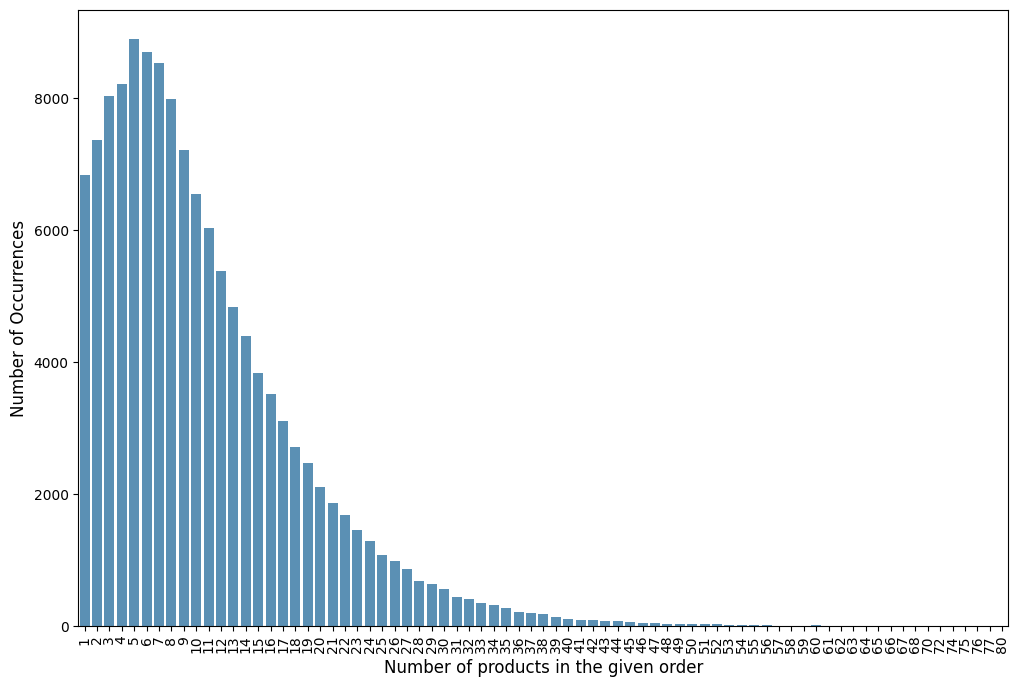

In [38]:
grouped_df = order_products_train_df.groupby("order_id")["add_to_cart_order"].aggregate("max").reset_index()
cnt_srs = grouped_df.add_to_cart_order.value_counts()

plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha=0.8)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Number of products in the given order',fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

-> 최댓값은 5에서 나타남.

In [39]:
products_df.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [40]:
aisles_df.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [41]:
departments_df.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [42]:
order_products_prior_df = pd.merge(order_products_prior_df, products_df, on='product_id', how='left')
order_products_prior_df = pd.merge(order_products_prior_df, aisles_df, on='aisle_id', how='left')
order_products_prior_df = pd.merge(order_products_prior_df, departments_df, on='department_id', how='left')
order_products_prior_df.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry


In [43]:
cnt_srs = order_products_prior_df['product_name'].value_counts().reset_index().head(20)
cnt_srs.columns = ['product_name', 'frequency_count']
cnt_srs

,product_name,frequency_count
0,Banana,472565
1,Bag of Organic Bananas,379450
2,Organic Strawberries,264683
3,Organic Baby Spinach,241921
4,Organic Hass Avocado,213584
5,Organic Avocado,176815
6,Large Lemon,152657
7,Strawberries,142951
8,Limes,140627
9,Organic Whole Milk,137905


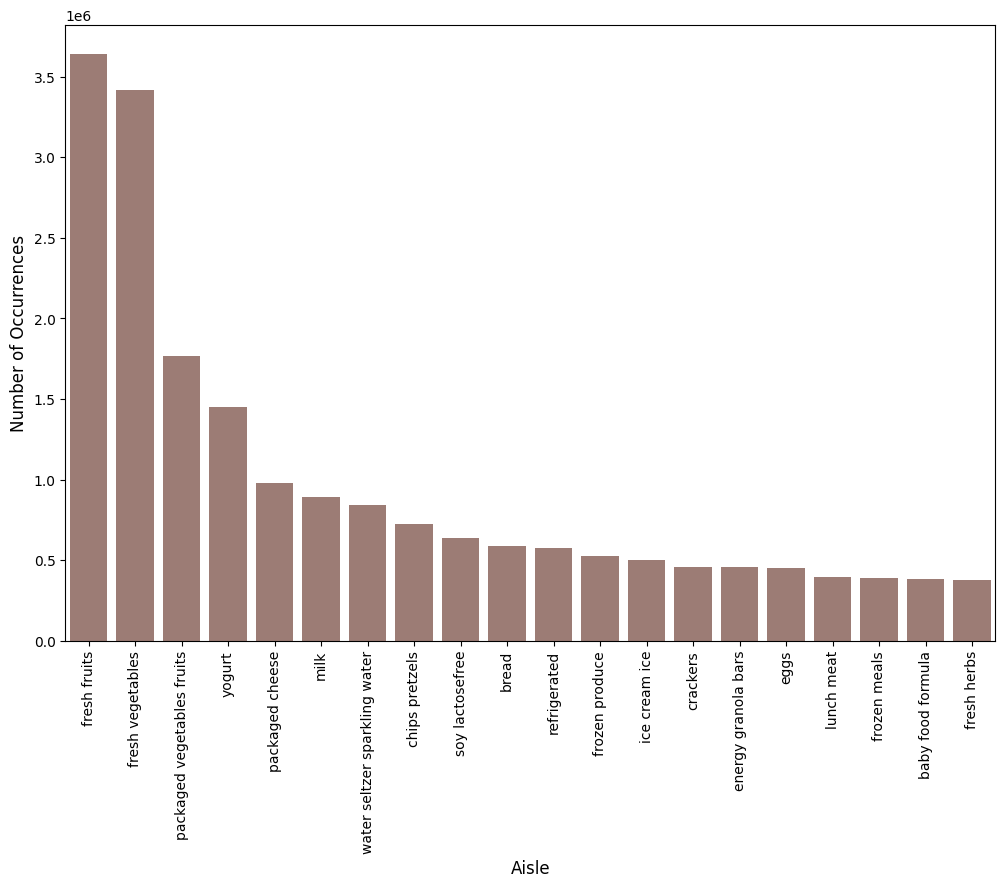

In [44]:
cnt_srs = order_products_prior_df['aisle'].value_counts().head(20)
plt.figure(figsize=(12,8))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values,alpha=0.8,color=color[5])
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Aisle', fontsize=12)
plt.xticks(rotation='vertical')
plt.show()

-> 가장 많이 판매된 상품 2개는 신선한 과일과 채소임.

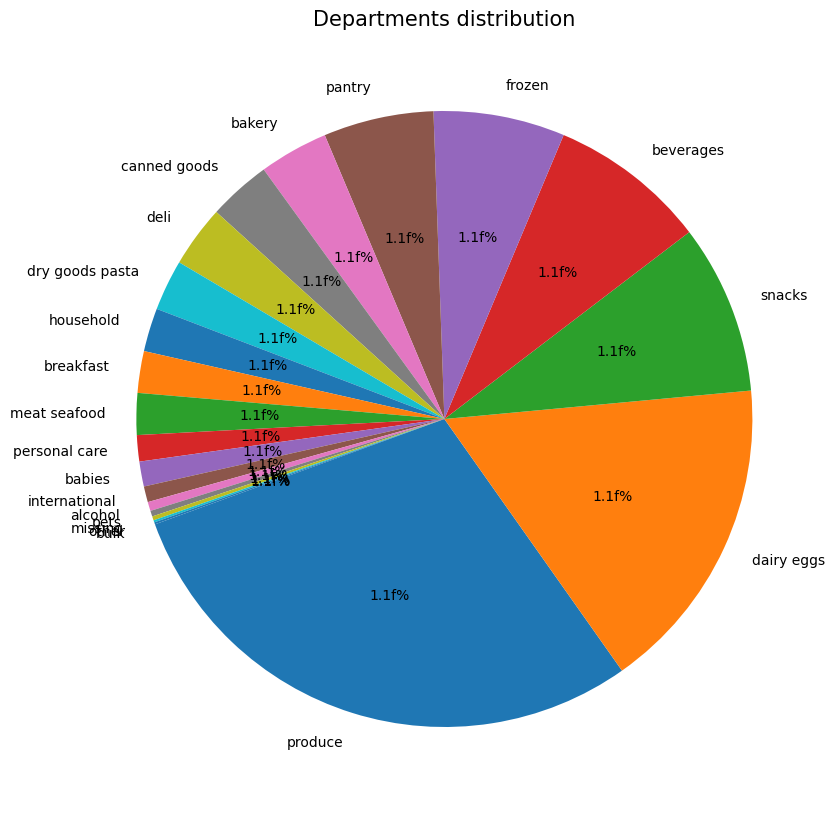

In [45]:
plt.figure(figsize=(10,10))
temp_series = order_products_prior_df['department'].value_counts()
labels = (np.array(temp_series.index))
sizes = (np.array((temp_series / temp_series.sum())*100))
plt.pie(sizes, labels=labels, autopct='1.1f%%',startangle=200)
plt.title("Departments distribution", fontsize=15)
plt.show()

-> 농산물 부분이 가장 큰 상품 부문임.

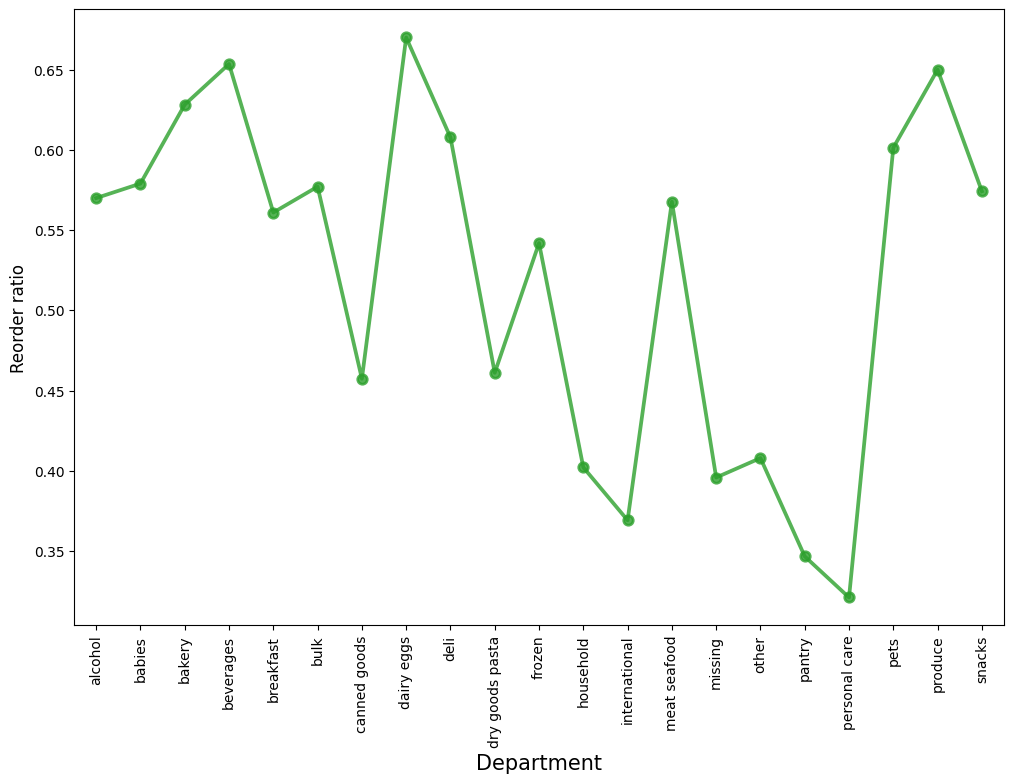

In [46]:
grouped_df = order_products_prior_df.groupby(["department"])["reordered"].aggregate("mean").reset_index()
plt.figure(figsize=(12,8))
sns.pointplot(x=grouped_df['department'].values, y=grouped_df['reordered'].values, alpha=0.8, color=color[2])
plt.ylabel('Reorder ratio', fontsize=12)
plt.xlabel('Department',fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

-> personal care이 재주문 비율 가장 낮고, dariy eggs가 재주문 비율 가장 높음.

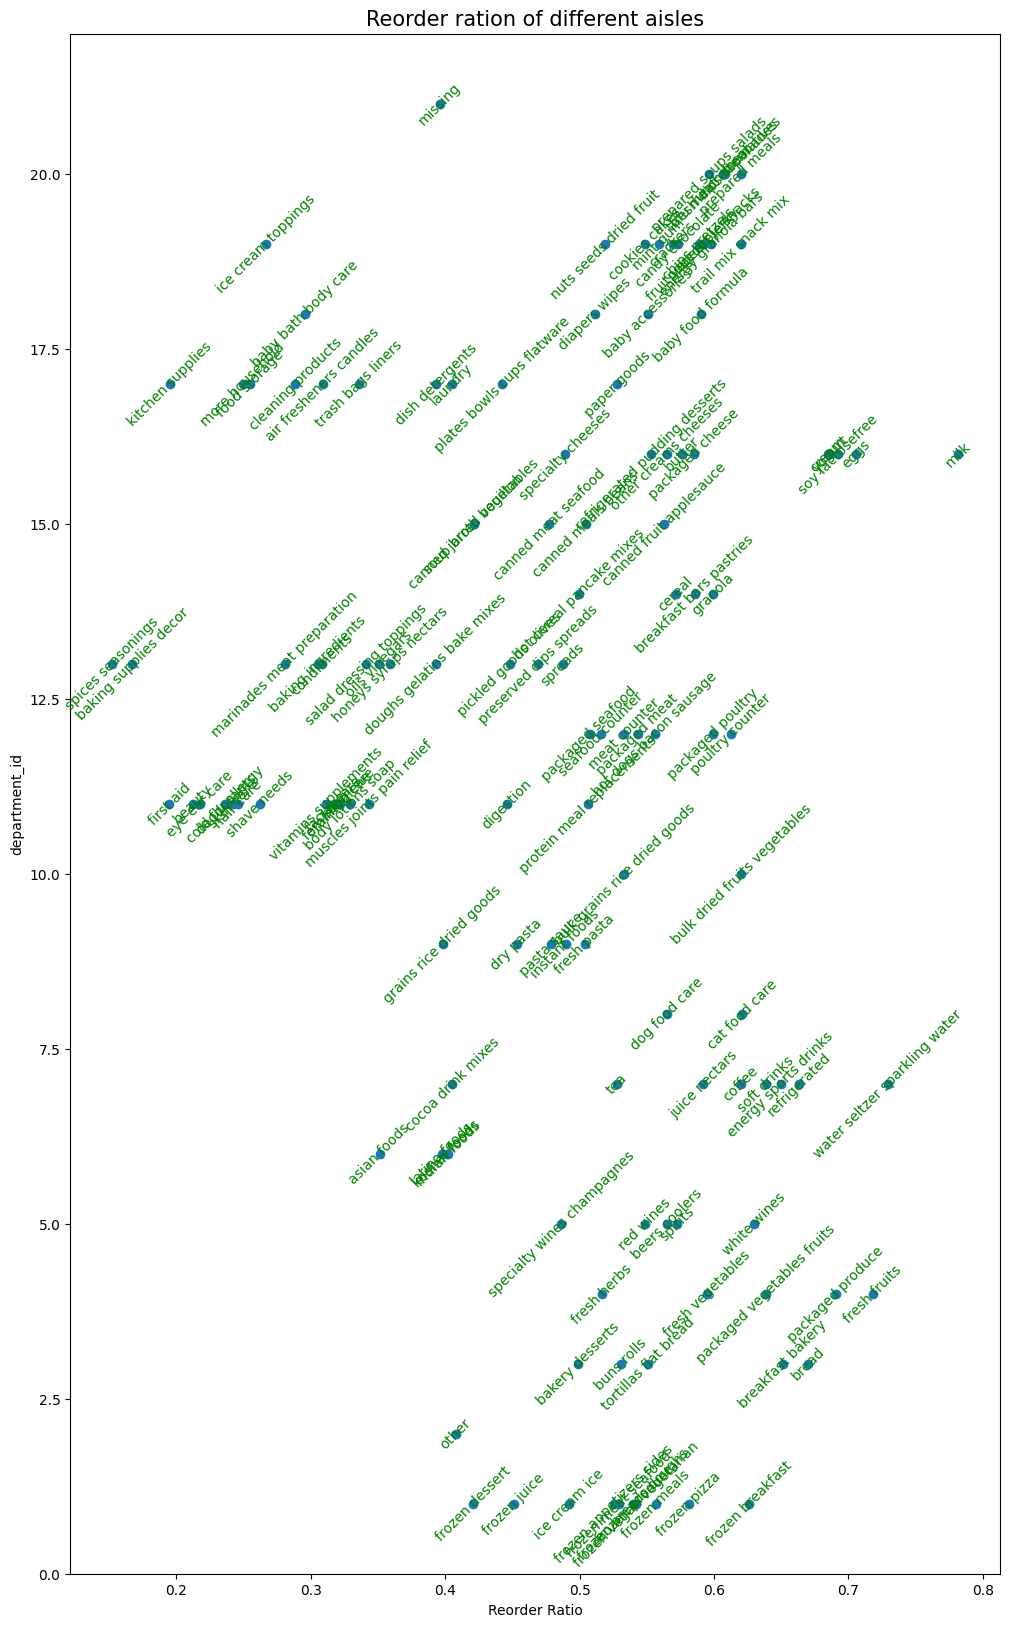

In [47]:
grouped_df = order_products_prior_df.groupby(["department_id","aisle"])["reordered"].aggregate("mean").reset_index()

fig,ax = plt.subplots(figsize=(12,20))
ax.scatter(grouped_df.reordered.values, grouped_df.department_id.values)
for i, txt in enumerate(grouped_df.aisle.values):
  ax.annotate(txt, (grouped_df.reordered.values[i],grouped_df.department_id.values[i]),rotation=45,ha='center',va='center', color='green')
plt.xlabel('Reorder Ratio')
plt.ylabel('department_id')
plt.title('Reorder ration of different aisles', fontsize=15)
plt.show()

/tmp/ipykernel_1039/1335241532.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  order_products_prior_df["add_to_cart_order_mod"].loc[order_products_prior_df["add_to_cart_order_mod"]>70]=70


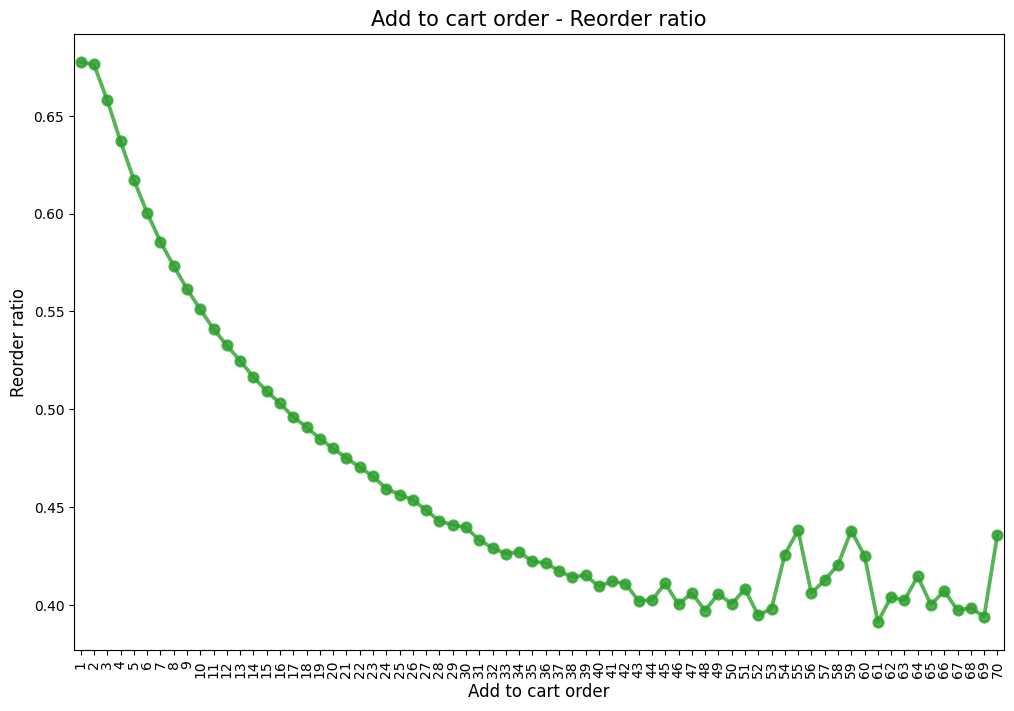

In [48]:
order_products_prior_df["add_to_cart_order_mod"] = order_products_prior_df["add_to_cart_order"].copy()
order_products_prior_df["add_to_cart_order_mod"].loc[order_products_prior_df["add_to_cart_order_mod"]>70]=70
grouped_df=order_products_prior_df.groupby(["add_to_cart_order_mod"])["reordered"].aggregate("mean").reset_index()

plt.figure(figsize=(12,8))
sns.pointplot(x=grouped_df['add_to_cart_order_mod'].values, y= grouped_df['reordered'].values, alpha=0.8, color=color[2])
plt.ylabel('Reorder ratio', fontsize=12)
plt.xlabel('Add to cart order', fontsize=12)
plt.title("Add to cart order - Reorder ratio", fontsize=15)
plt.xticks(rotation='vertical')
plt.show()

-> 장바구니에 먼저 추가된 상품일수록 재주문될 가능성이 높음.

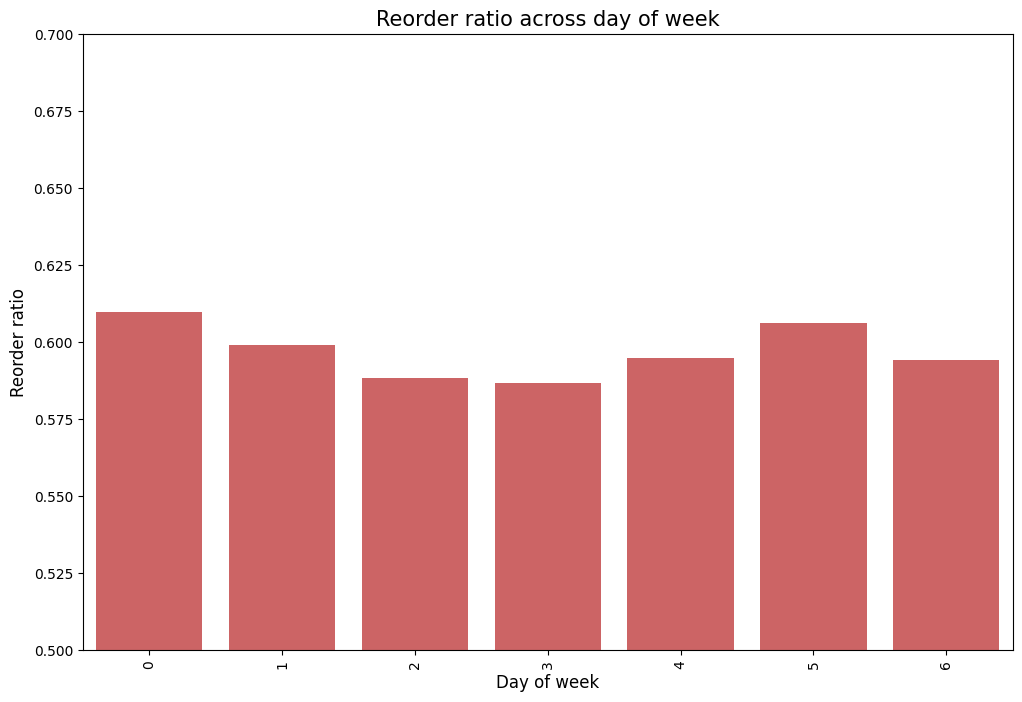

In [49]:
order_products_train_df = pd.merge(order_products_train_df, orders_df, on='order_id', how='left')
grouped_df=order_products_train_df.groupby(['order_dow'])['reordered'].aggregate('mean').reset_index()

plt.figure(figsize=(12,8))
sns.barplot(x=grouped_df['order_dow'].values, y=grouped_df['reordered'].values, alpha=0.8, color=color[3])
plt.ylabel('Reorder ratio', fontsize=12)
plt.xlabel('Day of week', fontsize=12)
plt.title("Reorder ratio across day of week", fontsize=15)
plt.xticks(rotation='vertical')
plt.ylim(0.5, 0.7)
plt.show()

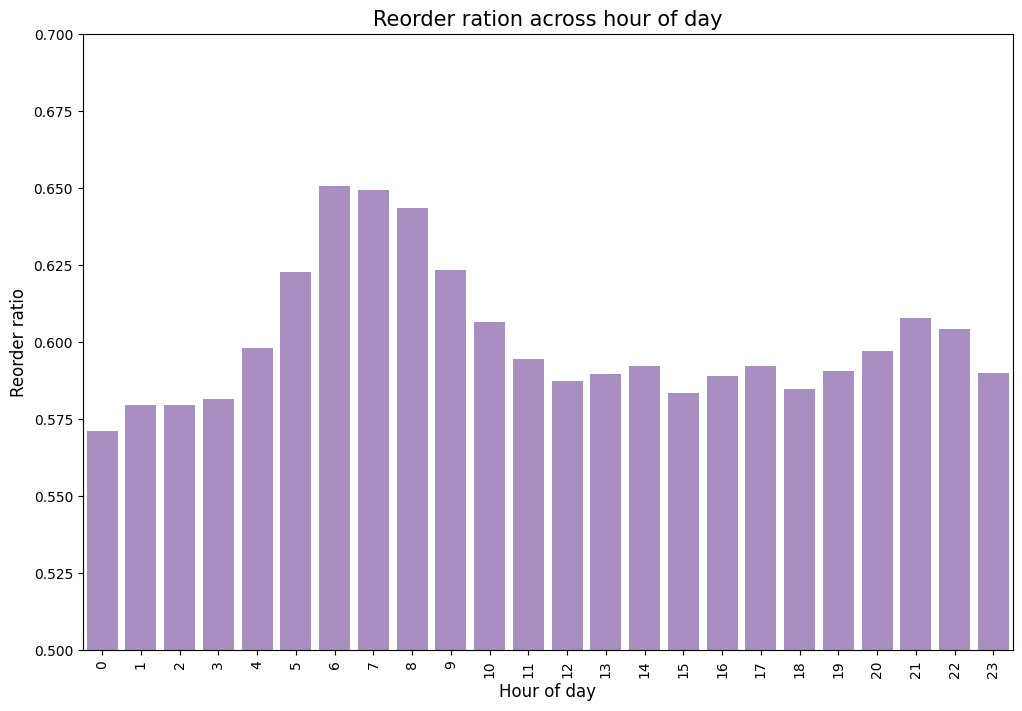

In [50]:
grouped_df = order_products_train_df.groupby(["order_hour_of_day"])['reordered'].aggregate('mean').reset_index()

plt.figure(figsize=(12,8))
sns.barplot(x=grouped_df['order_hour_of_day'].values, y=grouped_df['reordered'].values, alpha=0.8, color=color[4])
plt.ylabel('Reorder ratio',fontsize=12)
plt.xlabel('Hour of day', fontsize=12)
plt.title("Reorder ration across hour of day", fontsize=15)
plt.xticks(rotation='vertical')
plt.ylim(0.5,0.7)
plt.show()

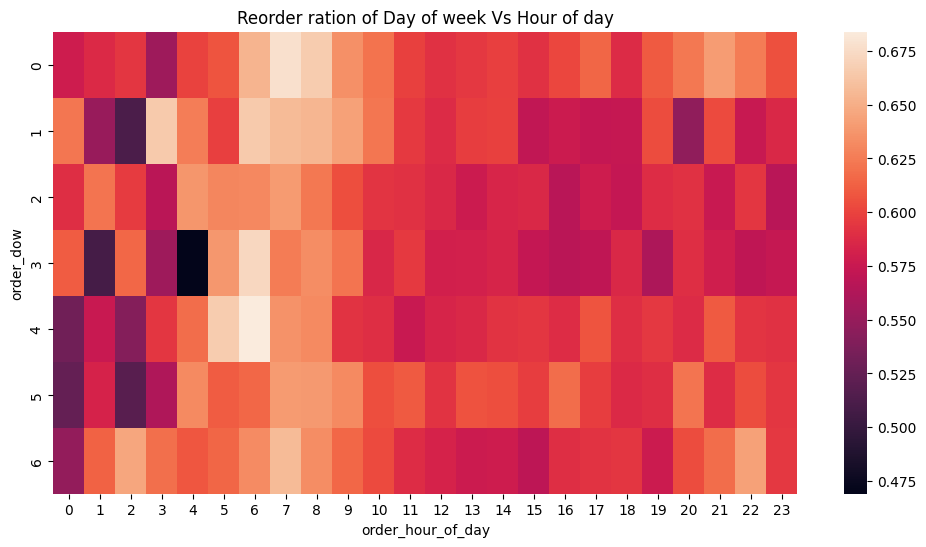

In [51]:
grouped_df = order_products_train_df.groupby(['order_dow', 'order_hour_of_day'])['reordered'].aggregate('mean').reset_index()
grouped_df=grouped_df.pivot(index='order_dow',columns='order_hour_of_day', values='reordered')

plt.figure(figsize=(12,6))
sns.heatmap(grouped_df)
plt.title("Reorder ration of Day of week Vs Hour of day")
plt.show()

# **\# 새로운 시각화**

질문: 주문 간격이 짧을수록 재주문 비율이 높을까?

In [3]:
# 주문 간격 구간 나누기
orders_df['order_interval'] = pd.cut(orders_df['days_since_prior_order'],bins=[-1, 7, 14, 21, 28, 30],labels=['Within 1 week', '1–2 weeks', '2–3 weeks', '3–4 weeks', '4+ weeks'])

In [4]:
# 주문 정보와 상품 정보 합치기
order_products_prior_df = pd.merge(order_products_prior_df,orders_df[['order_id', 'order_interval']],on='order_id',how='left')

In [5]:
# 주문 간격별 재주문율
grouped_df = order_products_prior_df.groupby(['order_interval'])['reordered'].mean().reset_index()
grouped_df

/tmp/ipykernel_8601/1982460411.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = order_products_prior_df.groupby(['order_interval'])['reordered'].mean().reset_index()


,order_interval,reordered
0,Within 1 week,0.674515
1,1–2 weeks,0.643934
2,2–3 weeks,0.595172
3,3–4 weeks,0.556977
4,4+ weeks,0.460336


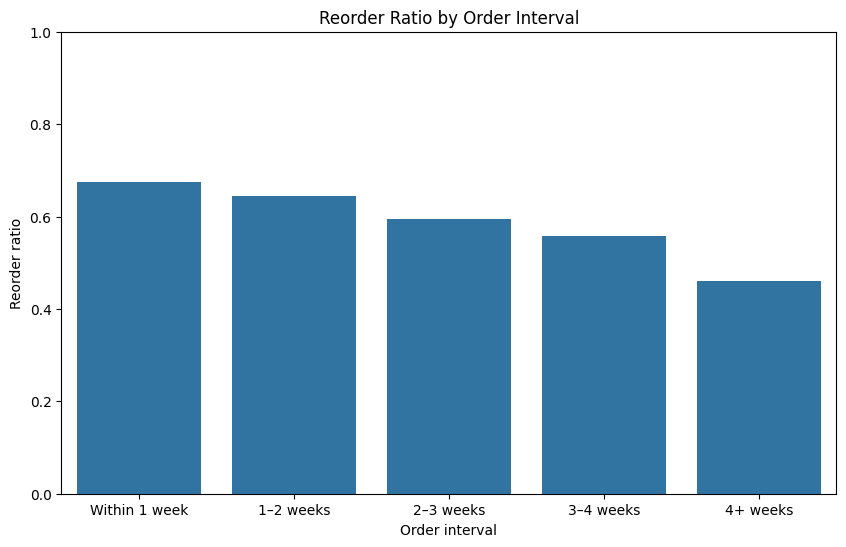

In [6]:
# 시각화
plt.figure(figsize=(10,6))

sns.barplot(x=grouped_df['order_interval'].values,y=grouped_df['reordered'].values)

plt.xlabel('Order interval')
plt.ylabel('Reorder ratio')
plt.title('Reorder Ratio by Order Interval')
plt.ylim(0,1)

plt.show()

### **\# 결과해석**

주문 간격이 짧은 그룹일수록 재주문 비율이 높았으며, 주문 간격이 길어질수록 재주문 비율이 점차 감소하는 경향이 나타났다.